FIRST 5 ROWS
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

DATASET SHAPE
(768, 9)

COLUMN NAMES
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

DATA TYPES
Pregnancies                   int64
Glucose                       int64
BloodPr

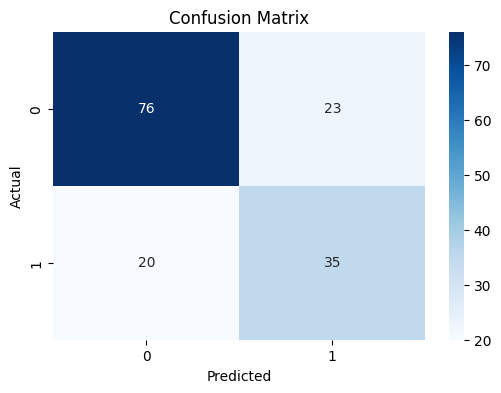

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dataset = pd.read_csv("diabetes.csv")

print("FIRST 5 ROWS")
print(dataset.head())

print("\nDATASET SHAPE")
print(dataset.shape)

print("\nCOLUMN NAMES")
print(dataset.columns)

print("\nDATA TYPES")
print(dataset.dtypes)

print("\nDATASET INFORMATION")
dataset.info()

print("\nSTATISTICAL SUMMARY")
print(dataset.describe())

print("\nMISSING VALUES")
print(dataset.isnull().sum())

print("\nDUPLICATE ROWS")
print(dataset.duplicated().sum())

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

imputer = SimpleImputer(missing_values=0, strategy="median")
dataset[cols] = imputer.fit_transform(dataset[cols])

X = dataset.drop("Outcome", axis=1)
y = dataset["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nACCURACY")
print(accuracy_score(y_test, y_pred))

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()